📊 9 adet sensör sinyali analiz ediliyor...



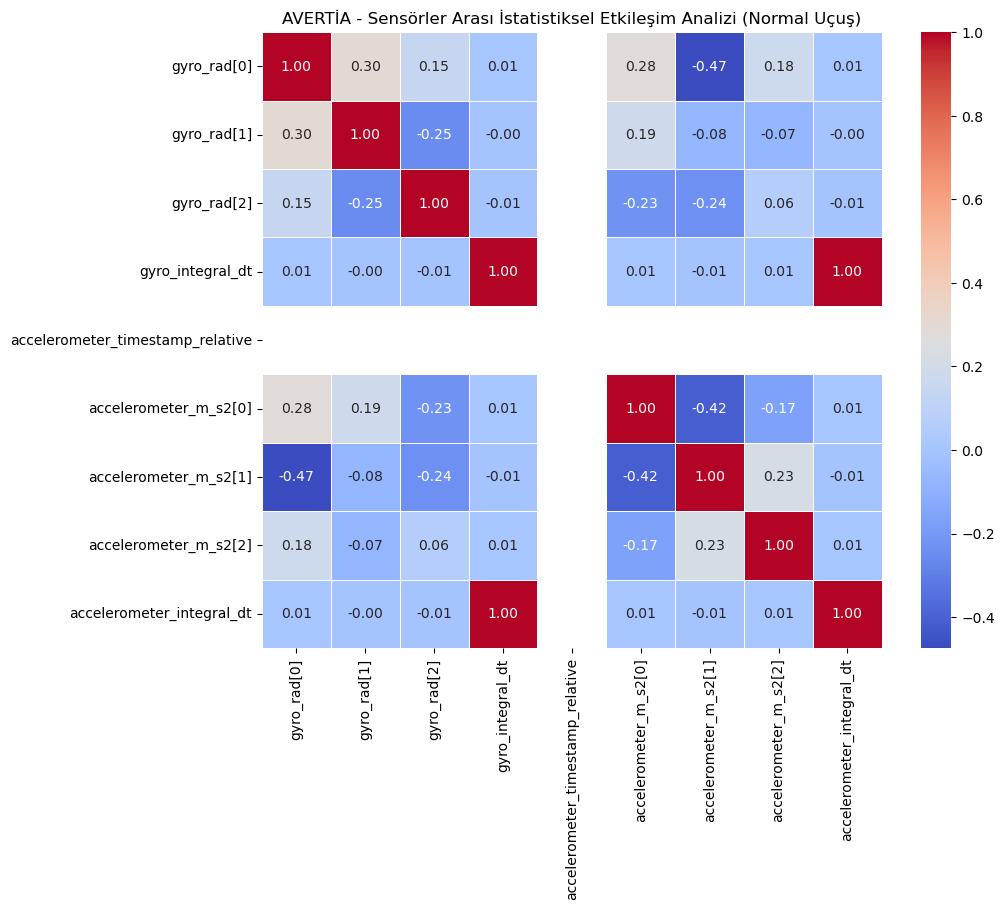

✅ Korelasyon analizi tamamlandı kanka. Bu grafik, sensörlerin normal uçuşta
birbiriyle olan fiziksel tutarlılığını jüriye matematiksel olarak kanıtlar!


In [2]:
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Kanka temiz uçuşlarından bir tanesinin sensor_combined veya local_position verisini buraya hedef göster
# Proje hedeflerindeki korelasyon analizini doğrulamak için kullanacağız.
temiz_ucush_yolu = r"C:\Users\feyza\Desktop\uav_project\data\processed\cleaned_train\00_02_49\00_02_49_sensor_combined_0.csv"

if os.path.exists(temiz_ucush_yolu):
    df = pd.read_csv(temiz_ucush_yolu)
    
    # İncelemek istediğimiz temel sinyal karakteristikleri (Dökümandaki 1. ve 2. madde için)
    # Gyro ve Accelerometer arasındaki ilişkileri seçiyoruz
    analiz_features = [col for col in df.columns if 'gyro' in col or 'accelerometer' in col]
    
    if len(analiz_features) > 0:
        print(f"📊 {len(analiz_features)} adet sensör sinyali analiz ediliyor...\n")
        
        # Pearson Korelasyon Matrisi Hesaplama
        korelasyon_matrisi = df[analiz_features].corr()
        
        # Isı Haritası Çizimi
        plt.figure(figsize=(10, 8))
        sns.heatmap(korelasyon_matrisi, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
        plt.title("AVERTİA - Sensörler Arası İstatistiksel Etkileşim Analizi (Normal Uçuş)", fontsize=12)
        plt.show()
        
        print("✅ Korelasyon analizi tamamlandı kanka. Bu grafik, sensörlerin normal uçuşta")
        print("birbiriyle olan fiziksel tutarlılığını jüriye matematiksel olarak kanıtlar!")
    else:
        print("❌ Dosyada gyro veya accelerometer kolonu bulunamadı.")
else:
    print("❌ Belirtilen test dosyası bulunamadı, yolu kontrol edelim kanka.")